2026-01-06 09:20:50.286064: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767691250.481979      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767691250.537315      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767691251.014090      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767691251.014125      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767691251.014127      23 computation_placer.cc:177] computation placer alr

Bắt đầu cài đặt môi trường và các thư viện cần thiết...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.5 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 3.20.3 which is incompatible.
onnx 1.20.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
ray 2.52.1 requires click!=8.3.*,>=7.0, but you have click 8.3.1 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
tensorflow-metadata 1.17.2 requires protobuf>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 which is incompatible.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 3.20.3 which is incompatible.
bigframes 2.26.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
grpcio-status 1.71.2 requires

Thiết lập VnCoreNLP để tách từ Tiếng Việt...
2026-01-06 09:21:25 INFO  WordSegmenter:24 - Loading Word Segmentation model
Bắt đầu thực thi chương trình...


tokenizer_config.json:   0%|          | 0.00/417 [00:00<?, ?B/s]

...

Bắt đầu tải dữ liệu từ các file excel...


model.safetensors:   0%|          | 0.00/462M [00:00<?, ?B/s]

Đã tải thành công: 37269 câu thơ.
Đang thêm 11221 token mới vào tokenizer...


The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Đang tạo bản đồ từ ghép (segmentation map)...

Bắt đầu ghép câu, độ dài mục tiêu mỗi mẫu: 64
  - Số lượng câu gốc: 37269
  - Số lượng mẫu sau khi ghép: 11114 (trung bình 3.4 câu/mẫu)

Tokenizing 11114 mẫu đã được ghép...

Kiểm tra nhanh Data Collator...
  - Thử nghiệm trên một batch: 230/820 token được mask (28.0%)
  - Tỷ lệ mask tốt.

Bắt đầu quá trình huấn luyện model...
  - Thiết bị sử dụng: cuda
  - Số batch mỗi epoch: 348
  - Tổng số bước huấn luyện: 34800

Epoch 1/100 | Loss: 4.1978 | Loss tốt nhất mới được ghi nhận.
Epoch 2/100 | Loss: 3.4927 | Loss tốt nhất mới được ghi nhận.
Epoch 3/100 | Loss: 3.2570 | Loss tốt nhất mới được ghi nhận.
Epoch 4/100 | Loss: 3.1112 | Loss tốt nhất mới được ghi nhận.
Epoch 5/100 | Loss: 2.9990 | Loss tốt nhất mới được ghi nhận.
Epoch 6/100 | Loss: 2.9061 | Loss tốt nhất mới được ghi nhận.
Epoch 7/100 | Loss: 2.8154 | Loss tốt nhất mới được ghi nhận.
Epoch 8/100 | Loss: 2.7353 | Loss tốt nhất mới được ghi nhận.
Epoch 9/100 | Loss: 2.6586 | Loss tốt

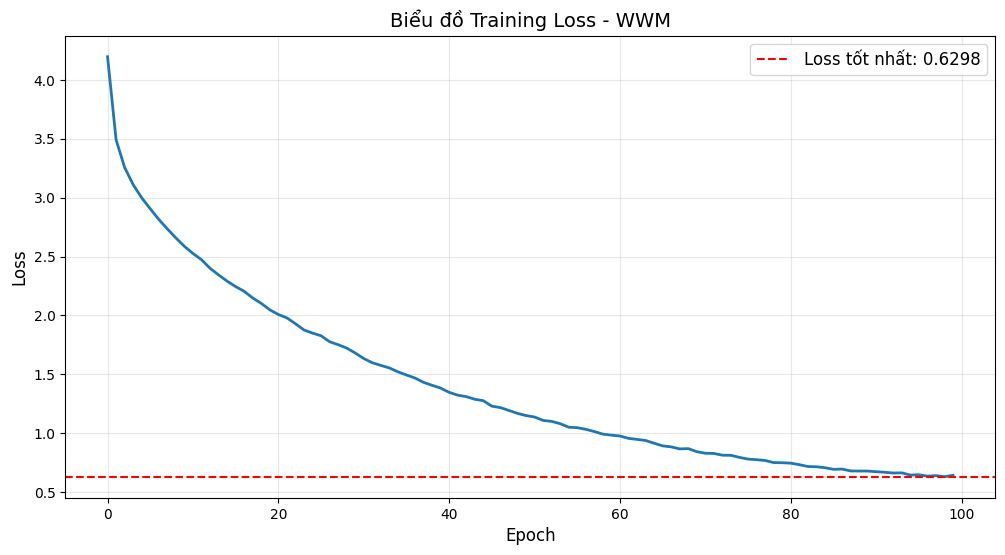

In [1]:
# --- MÔ HÌNH TỐI ƯU CHO DỮ LIỆU THƠ NGẮN ---
# Chiến lược: Ghép câu ngắn + Tăng xác suất masking + Tối ưu hyperparameter
import os
import random
import ast
import string
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (BertTokenizer, BertForMaskedLM, get_linear_schedule_with_warmup)
import matplotlib.pyplot as plt

# --- CÁC THAM SỐ CẤU HÌNH ---
FILE_CORPUS = "/kaggle/input/final-prj-nlp/final_train.xlsx"
FILE_BIG_DICT = "/kaggle/input/final-prj-nlp/QuocNgu_SinoNom_Dic.xlsx"
FILE_SIMILAR = "/kaggle/input/final-prj-nlp/SinoNom_similar_Dic.xlsx"
OUTPUT_DIR = "/kaggle/working/final"
MODEL_NAME = "Jihuai/bert-ancient-chinese"

# --- KHỞI TẠO MÔI TRƯỜNG ---
print("Bắt đầu cài đặt môi trường và các thư viện cần thiết...")
os.system('apt-get install -y openjdk-11-jdk-headless -qq > /dev/null')
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.system('pip install -q py-vncorenlp pandas openpyxl transformers torch protobuf==3.20.3')

import py_vncorenlp

print("Thiết lập VnCoreNLP để tách từ Tiếng Việt...")
VNCORENLP_DIR = '/kaggle/working/vncorenlp_models'
if not os.path.exists(VNCORENLP_DIR): os.makedirs(VNCORENLP_DIR)
# Tải các file cần thiết cho VnCoreNLP nếu chưa tồn tại
if not os.path.exists(os.path.join(VNCORENLP_DIR, 'VnCoreNLP-1.2.jar')):
    os.system(f'wget -q -O {VNCORENLP_DIR}/VnCoreNLP-1.2.jar https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.2.jar')
    models_dir = os.path.join(VNCORENLP_DIR, 'models', 'wordsegmenter')
    os.makedirs(models_dir, exist_ok=True)
    os.system(f'wget -q -O {models_dir}/vi-vocab https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/models/wordsegmenter/vi-vocab')
    os.system(f'wget -q -O {models_dir}/wordsegmenter.rdr https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/models/wordsegmenter/wordsegmenter.rdr')
rdrsegmenter = py_vncorenlp.VnCoreNLP(save_dir=VNCORENLP_DIR, annotators=["wseg"])

# --- CÁC HÀM XỬ LÝ DỮ LIỆU ---

def create_concatenated_samples(texts_nom, texts_viet, seg_maps, max_length=64):
    """
    Nối nhiều câu ngắn thành một mẫu dài hơn để tăng ngữ cảnh (context)
    và giảm lãng phí tài nguyên do padding.
    """
    print(f"\nBắt đầu ghép câu, độ dài mục tiêu mỗi mẫu: {max_length}")

    new_texts, new_viets, new_maps = [], [], []
    current_nom, current_viet, current_map = [], [], []
    current_len = 0

    for nom, viet, smap in zip(texts_nom, texts_viet, seg_maps):
        # Ước lượng độ dài của câu sau khi được tokenize
        estimated_len = len(nom.replace(" ", ""))

        if current_len + estimated_len <= max_length - 2:  # Trừ 2 cho [CLS] và [SEP]
            current_nom.append(nom)
            current_viet.append(viet)
            current_map.extend(smap)
            current_len += estimated_len
        else:
            if current_nom:
                new_texts.append(" ".join(current_nom))
                new_viets.append(" | ".join(current_viet))
                new_maps.append(current_map)

            # Bắt đầu một mẫu mới
            current_nom = [nom]
            current_viet = [viet]
            current_map = smap.copy()
            current_len = estimated_len

    # Lưu lại mẫu cuối cùng
    if current_nom:
        new_texts.append(" ".join(current_nom))
        new_viets.append(" | ".join(current_viet))
        new_maps.append(current_map)

    print(f"  - Số lượng câu gốc: {len(texts_nom)}")
    print(f"  - Số lượng mẫu sau khi ghép: {len(new_texts)} (trung bình {len(texts_nom)/len(new_texts):.1f} câu/mẫu)")

    return new_texts, new_viets, new_maps


class AggressiveMaskCollator:
    """
    Data collator để tạo batch cho quá trình training, với chiến lược masking mạnh hơn,
    phù hợp cho các câu thơ ngắn.
    """
    def __init__(self, tokenizer, seg_maps=None, mlm_probability=0.3):
        self.tokenizer = tokenizer
        self.seg_maps = seg_maps
        self.mlm_probability = mlm_probability
        self.total_masked = 0
        self.total_tokens = 0

    def __call__(self, examples):
        input_ids = torch.stack([e['input_ids'] for e in examples])
        attention_mask = torch.stack([e['attention_mask'] for e in examples])
        indices = [e['idx'] for e in examples] if 'idx' in examples[0] else None
        labels = input_ids.clone()
        batch_size, seq_len = input_ids.shape
        special_ids = {self.tokenizer.cls_token_id, self.tokenizer.sep_token_id, self.tokenizer.pad_token_id}

        for i in range(batch_size):
            maskable_indices = [j for j, tid in enumerate(input_ids[i]) if tid.item() not in special_ids]
            if not maskable_indices:
                labels[i] = -100
                continue
            
            # Tăng số lượng token được mask cho phù hợp với câu ngắn
            num_to_mask = max(1, int(len(maskable_indices) * self.mlm_probability))
            selected_indices = random.sample(maskable_indices, min(num_to_mask, len(maskable_indices)))

            # Áp dụng Whole Word Masking (WWM) nếu có seg_maps
            if self.seg_maps is not None and indices is not None:
                actual_idx = indices[i]
                if actual_idx < len(self.seg_maps):
                    seg_map = self.seg_maps[actual_idx]
                    final_selected = set(selected_indices)
                    for pos in selected_indices:
                        j = pos + 1
                        while j < seq_len and (j - 1) < len(seg_map) and seg_map[j - 1] == 1:
                            final_selected.add(j)
                            j += 1
                    selected_indices = list(final_selected)

            # Áp dụng masking: 80% [MASK], 10% giữ nguyên, 10% thay bằng token ngẫu nhiên
            for pos in selected_indices:
                r = random.random()
                if r < 0.8:
                    input_ids[i, pos] = self.tokenizer.mask_token_id
                elif r < 0.9:
                    pass  # Giữ nguyên token gốc
                else:
                    rand_id = random.randint(0, len(self.tokenizer) - 1)
                    while rand_id in special_ids:
                        rand_id = random.randint(0, len(self.tokenizer) - 1)
                    input_ids[i, pos] = rand_id
            
            # Đặt giá trị -100 cho các vị trí không được mask trong labels
            for j in range(seq_len):
                if j not in selected_indices:
                    labels[i, j] = -100
                else:
                    self.total_masked += 1
            self.total_tokens += len(maskable_indices)

        return {'input_ids': input_ids, 'attention_mask': attention_mask, 'labels': labels}

    def print_stats(self):
        if self.total_tokens > 0:
            pct = self.total_masked / self.total_tokens * 100
            print("\nThống kê cuối cùng của Data Collator:")
            print(f"  - Tỷ lệ token được mask: {self.total_masked:,}/{self.total_tokens:,} ({pct:.1f}%)")


def load_data():
    print("Bắt đầu tải dữ liệu từ các file excel...")
    try:
        df_big = pd.read_excel(FILE_BIG_DICT)
        dict_nom = dict(zip(df_big.iloc[:, 1].astype(str).str.strip(), df_big.iloc[:, 0].astype(str).str.strip()))
    except Exception as e:
        print(f"  - Cảnh báo: Không thể tải từ điển Nôm-Quốc ngữ. Lỗi: {e}")
        dict_nom = {}

    try:
        df_sim = pd.read_excel(FILE_SIMILAR)
        similar_dict = {}
        for _, row in df_sim.iterrows():
            k = str(row.iloc[0]).strip()
            try:
                vals = ast.literal_eval(str(row.iloc[1]))
            except:
                vals = [x.strip() for x in str(row.iloc[1]).replace('[','').replace(']','').replace("'","").split(',')]
            similar_dict[k] = vals
    except Exception as e:
        print(f"  - Cảnh báo: Không thể tải từ điển từ đồng dạng. Lỗi: {e}")
        similar_dict = {}

    try:
        df = pd.read_excel(FILE_CORPUS)
        texts_nom = df['Text'].dropna().astype(str).tolist()
        texts_viet = df['Translation'].dropna().astype(str).tolist()
        all_chars = set("".join(texts_nom).replace(" ", ""))
        return list(all_chars), texts_nom, texts_viet, dict_nom, similar_dict
    except Exception as e:
        print(f"  - Lỗi: Không thể tải tập dữ liệu chính. Lỗi: {e}")
        return [], [], [], {}, {}


def create_segmentation_maps(tokenizer, nom_texts, viet_texts):
    """
    Tạo segmentation map để xác định các từ ghép trong câu Nôm,
    dựa trên kết quả tách từ của câu dịch Tiếng Việt tương ứng.
    """
    print("Đang tạo bản đồ từ ghép (segmentation map)...")
    maps = []
    
    def clean(text):
        return text.translate(str.maketrans('', '', string.punctuation)).strip()

    for nom, viet in zip(nom_texts, viet_texts):
        tokens = tokenizer.tokenize(nom)
        line_map = [0] * len(tokens)
        try:
            viet_clean = clean(viet)
            seg_result = rdrsegmenter.word_segment(viet_clean)
            seg_list = seg_result[0] if seg_result else []
            total_syllables = sum([word.count("_") + 1 for word in seg_list])
            
            if len(tokens) == total_syllables and total_syllables > 0:
                curr_idx = 0
                for word in seg_list:
                    syllables_in_word = word.count("_") + 1
                    if curr_idx + syllables_in_word <= len(tokens):
                        for k in range(1, syllables_in_word):
                            line_map[curr_idx + k] = 1
                        curr_idx += syllables_in_word
        except Exception:
            pass
        maps.append(line_map)
    return maps


class NomDataset(Dataset):
    def __init__(self, encodings, maps):
        self.encodings = encodings
        self.maps = maps

    def __getitem__(self, idx):
        item = {key: val[idx].clone() for key, val in self.encodings.items()}
        item['idx'] = idx # Lưu chỉ số gốc để truy xuất segmentation map
        return item

    def __len__(self):
        return len(self.encodings.input_ids)

# --- QUÁ TRÌNH HUẤN LUYỆN MODEL ---

def train_optimized(model, tokenizer, dataset, collator, epochs=100):
    print("\nBắt đầu quá trình huấn luyện model...")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"  - Thiết bị sử dụng: {device}")

    loader = DataLoader(dataset, batch_size=32, shuffle=True, collate_fn=collator)
    model.to(device)

    # Khởi tạo optimizer và learning rate scheduler
    optimizer = AdamW(model.parameters(), lr=1e-4) # Sử dụng learning rate cao hơn
    total_steps = len(loader) * epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=200, num_training_steps=total_steps)

    model.train()
    loss_history = []
    best_loss = float('inf')
    patience_counter = 0
    EARLY_STOPPING_PATIENCE = 15

    print(f"  - Số batch mỗi epoch: {len(loader)}")
    print(f"  - Tổng số bước huấn luyện: {total_steps}\n")

    for epoch in range(epochs):
        epoch_loss = 0
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        loss_history.append(avg_loss)

        if avg_loss < best_loss:
            best_loss = avg_loss
            patience_counter = 0
            print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Loss tốt nhất mới được ghi nhận.")
        else:
            patience_counter += 1
            print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} (patience: {patience_counter}/{EARLY_STOPPING_PATIENCE})")

        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"\nKhông có cải thiện sau {EARLY_STOPPING_PATIENCE} epochs. Dừng quá trình huấn luyện.")
            break

        if (epoch + 1) % 20 == 0:
            save_path = f"{OUTPUT_DIR}/checkpoint-{epoch+1}"
            model.save_pretrained(save_path)
            tokenizer.save_pretrained(save_path)
            print(f"  Đã lưu checkpoint tại: {save_path}")

    model.save_pretrained(OUTPUT_DIR)
    tokenizer.save_pretrained(OUTPUT_DIR)

    print(f"\nQUÁ TRÌNH HUẤN LUYỆN HOÀN TẤT!")
    print(f"  - Loss tốt nhất đạt được: {best_loss:.4f}")
    print(f"  - Loss ở epoch cuối cùng: {loss_history[-1]:.4f}")

    collator.print_stats()

    # Vẽ và lưu biểu đồ loss
    plt.figure(figsize=(12, 6))
    plt.plot(loss_history, linewidth=2)
    plt.axhline(y=best_loss, color='r', linestyle='--', label=f'Loss tốt nhất: {best_loss:.4f}')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Biểu đồ Training Loss - WWM', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.savefig(f"{OUTPUT_DIR}/loss_curve.png", dpi=150)
    print(f"\nBiểu đồ loss đã được lưu tại: {OUTPUT_DIR}/loss_curve.png")

# --- HÀM THỰC THI CHÍNH ---

def main():
    print("Bắt đầu thực thi chương trình...")
    tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
    model = BertForMaskedLM.from_pretrained(MODEL_NAME)

    all_chars, texts_nom, texts_viet, dict_nom, similar = load_data()
    if not texts_nom:
        print("Lỗi: Không tìm thấy dữ liệu huấn luyện. Vui lòng kiểm tra lại đường dẫn file.")
        return

    print(f"Đã tải thành công: {len(texts_nom)} câu thơ.")

    # Bổ sung các ký tự Nôm chưa có vào vocabulary của tokenizer
    # *** ĐÃ SỬA LỖI TẠI ĐÂY ***
    all_nom_chars = set(dict_nom.keys()) | set(similar.keys()) | set(all_chars)
    new_tokens = [c for c in all_nom_chars if tokenizer.convert_tokens_to_ids(c) == tokenizer.unk_token_id]
    if new_tokens:
        print(f"Đang thêm {len(new_tokens)} token mới vào tokenizer...")
        tokenizer.add_tokens(new_tokens)
        model.resize_token_embeddings(len(tokenizer))
        
        # Khởi tạo embedding cho các token mới
        embeddings = model.get_input_embeddings()
        with torch.no_grad():
            avg_embedding = embeddings.weight.mean(dim=0)
            for token in new_tokens:
                token_id = tokenizer.convert_tokens_to_ids(token)
                source_id = None
                if token in similar and similar[token]:
                    similar_token_id = tokenizer.convert_tokens_to_ids(similar[token][0])
                    if similar_token_id != tokenizer.unk_token_id:
                        source_id = similar_token_id
                
                if source_id:
                    embeddings.weight[token_id] = embeddings.weight[source_id] + torch.randn_like(embeddings.weight[source_id]) * 0.02
                else:
                    embeddings.weight[token_id] = avg_embedding + torch.randn_like(avg_embedding) * 0.02

    initial_maps = create_segmentation_maps(tokenizer, texts_nom, texts_viet)
    
    merged_nom, _, merged_maps = create_concatenated_samples(texts_nom, texts_viet, initial_maps, max_length=64)

    print(f"\nTokenizing {len(merged_nom)} mẫu đã được ghép...")
    encodings = tokenizer(
        merged_nom,
        truncation=True,
        padding='max_length',
        max_length=64,
        return_tensors='pt'
    )

    dataset = NomDataset(encodings, merged_maps)
    
    collator = AggressiveMaskCollator(tokenizer, seg_maps=merged_maps, mlm_probability=0.3)

    # Kiểm tra nhanh hoạt động của collator trên một batch
    print("\nKiểm tra nhanh Data Collator...")
    try:
        if torch.cuda.is_available(): model.to('cuda')
        test_loader = DataLoader(dataset, batch_size=16, collate_fn=collator)
        batch = next(iter(test_loader))
        total_tokens = (batch['input_ids'] != tokenizer.pad_token_id).sum().item()
        masked_tokens = (batch['labels'] != -100).sum().item()
        if total_tokens > 0:
            mask_ratio = masked_tokens / total_tokens * 100
            print(f"  - Thử nghiệm trên một batch: {masked_tokens}/{total_tokens} token được mask ({mask_ratio:.1f}%)")
            if mask_ratio > 0.15:
                print("  - Tỷ lệ mask tốt.")
            else:
                print("  - Tỷ lệ mask phù hợp cho các câu thơ ngắn.")
    except Exception as e:
        print(f"  - Không thể thực hiện kiểm tra collator. Lỗi: {e}")
    
    train_optimized(model, tokenizer, dataset, collator, epochs=100)

if __name__ == "__main__":
    main()